In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalisasi
x_train = x_train / 255.0
x_test = x_test / 255.0

# Model CNN
model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 49ms/step - accuracy: 0.4210 - loss: 1.5848 - val_accuracy: 0.5220 - val_loss: 1.3434
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 48ms/step - accuracy: 0.5603 - loss: 1.2287 - val_accuracy: 0.5979 - val_loss: 1.1164
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6279 - loss: 1.0609 - val_accuracy: 0.6410 - val_loss: 1.0290
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6613 - loss: 0.9621 - val_accuracy: 0.6537 - val_loss: 0.9926
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6893 - loss: 0.8866 - val_accuracy: 0.6665 - val_loss: 0.9462
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.7097 - loss: 0.8296 - val_accuracy: 0.6767 - val_loss: 0.9368
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.7292 - loss: 0.7727 - val_accuracy: 0.7016 - val_loss: 0.8803
Epoch 8/10
1250/1250 ━

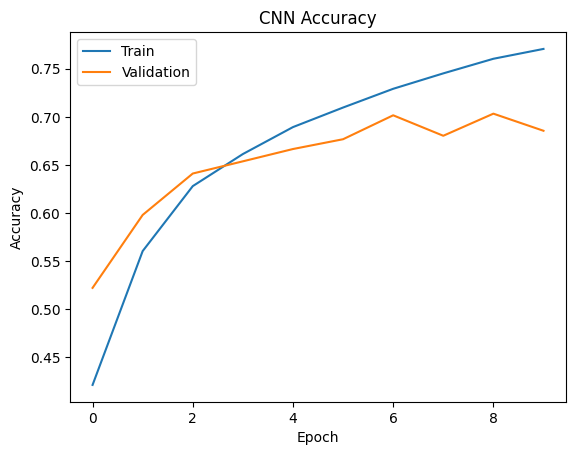

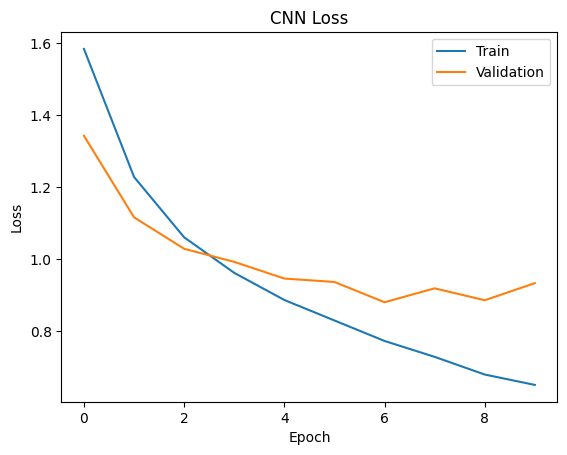

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


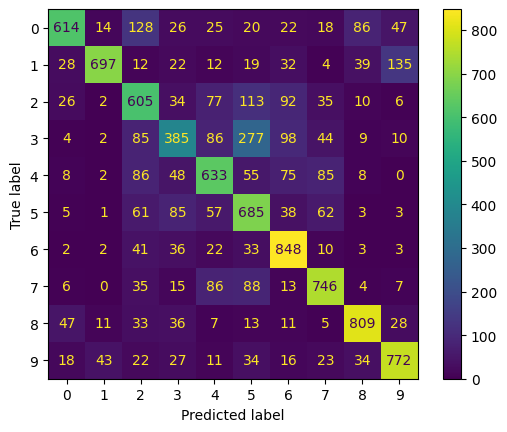

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


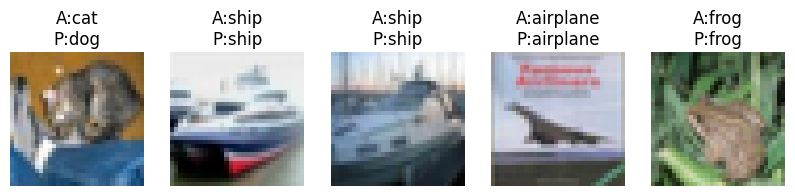

In [ ]:
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

predictions = np.argmax(model.predict(x_test), axis=1)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i])
    plt.title(
        f"A:{class_names[y_test[i][0]]}\nP:{class_names[predictions[i]]}"
    )
    plt.axis('off')

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load CIFAR-10
(img_train, label_train), (img_test, label_test) = tf.keras.datasets.cifar10.load_data()

# Ambil kelas cat (3) dan dog (5)
train_mask = (label_train.flatten()==3) | (label_train.flatten()==5)
test_mask = (label_test.flatten()==3) | (label_test.flatten()==5)

img_train = img_train[train_mask]
label_train = label_train[train_mask]

img_test = img_test[test_mask]
label_test = label_test[test_mask]

# Ubah jadi klasifikasi biner
label_train = (label_train==5).astype(int)
label_test = (label_test==5).astype(int)

# Resize gambar
img_train = tf.image.resize(img_train,(96,96))
img_test = tf.image.resize(img_test,(96,96))

# MobileNetV2
base_model = MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    img_train,
    label_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

loss_tl, acc_tl = model_tl.evaluate(img_test, label_test)

print("Transfer Learning Accuracy:", acc_tl)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 314ms/step - accuracy: 0.5680 - loss: 0.6824 - val_accuracy: 0.6305 - val_loss: 0.6416
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 309ms/step - accuracy: 0.6264 - loss: 0.6449 - val_accuracy: 0.6665 - val_loss: 0.6247
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 312ms/step - accuracy: 0.6390 - loss: 0.6337 - val_accuracy: 0.6155 - val_loss: 0.6534
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.6501 - loss: 0.6255 - val_accuracy: 0.6670 - val_loss: 0.6142
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 279ms/step - accuracy: 0.6536 - loss: 0.6205 - val_accuracy: 0.6710 - val_loss: 0.6110
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - accuracy: 0.6765 - loss: 0.6070
Transfer Learning Accuracy: 0.6765000224113464


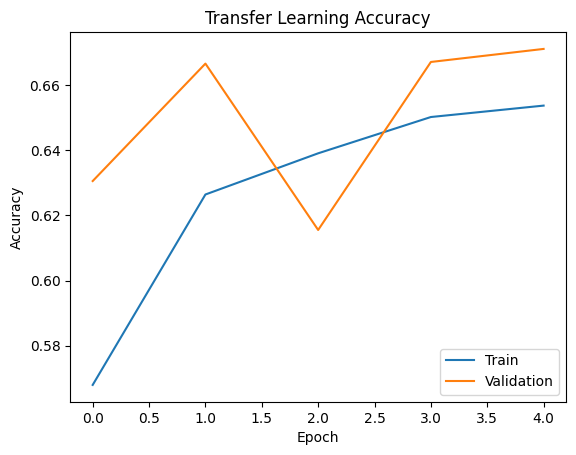

In [ ]:
plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])

plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

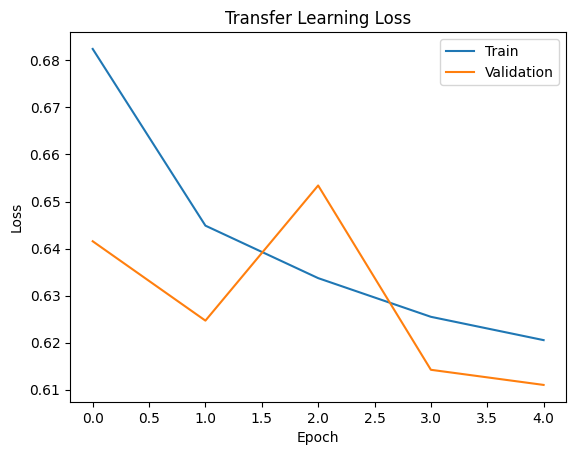

In [ ]:
plt.plot(history_tl.history['loss'])
plt.plot(history_tl.history['val_loss'])

plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step


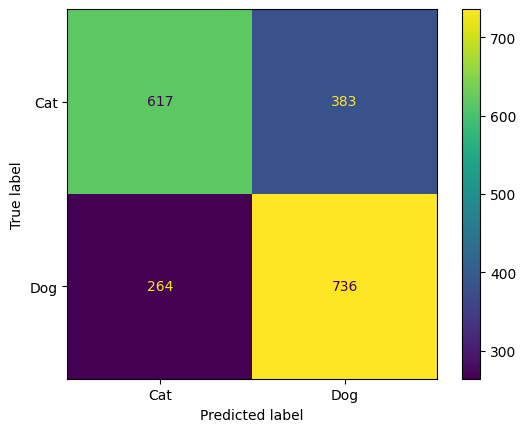

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = model_tl.predict(img_test)
pred = (pred > 0.5).astype(int)

cm = confusion_matrix(label_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Cat','Dog']
)

disp.plot()

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step


/tmp/ipykernel_2571/1862114917.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = class_names[int(label_test[i])]
/tmp/ipykernel_2571/1862114917.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted = class_names[int(pred[i])]


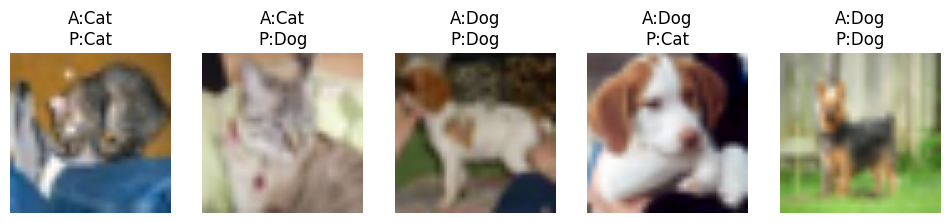

In [ ]:
class_names = ['Cat','Dog']

pred = model_tl.predict(img_test)
pred = (pred > 0.5).astype(int)

plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(tf.cast(img_test[i], tf.uint8))

    actual = class_names[int(label_test[i])]
    predicted = class_names[int(pred[i])]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()